### Ingestão de Big Data e Avaliação Preguiçosa (*Lazy Evaluation*)

Nesta primeira etapa, enfrentamos o desafio clássico da Engenharia de Dados: processar um ficheiro superior a 1.5 GB contendo o registo de transações de Alta Frequência (HFT) da Binance, com milhões de linhas ao nível do milissegundo.

**Decisões Técnicas:**
1. **Abandono do Pandas:** Tentar carregar este volume de dados com `pd.read_csv()` causaria o esgotamento da Memória RAM (Out of Memory Error).
2. **Uso do `pl.scan_csv()`:** Lemos o ficheiro criando apenas um "plano de execução" (Modo Lazy), sem trazer os dados para a memória.
3. **Conversão para Parquet (`sink_parquet`):** Executamos a limpeza de colunas em *streaming* e guardamos o resultado no formato `.parquet`. Esta arquitetura colunar reduz drasticamente o tamanho do ficheiro e permite leituras até 10x mais rápidas nas próximas etapas da análise.

In [1]:
import polars as pl
import time
import os

# Definição dos caminhos da nossa arquitetura
csv_bruto = r'C:\Users\Matheus.sfelipe\Documents\UC1\WHALE_WATCHER\dado_bruto\BTCUSDT-trades-2026-04.csv'
pasta_destino = 'dados/dados_processados'
parquet_otimizado = f'{pasta_destino}/historico_hft_otimizado.parquet'

# CORREÇÃO DA INFRAESTRUTURA: Garante que a pasta de destino existe antes de salvar
os.makedirs(pasta_destino, exist_ok=True)

# O arquivo da Binance não possui cabeçalho nativo
colunas_binance = [
    "id_trade", "preco", "quantidade_btc", "volume_dolar", 
    "timestamp_ms", "is_buyer_maker", "is_best_match"
]

print("A iniciar o pipeline de Big Data: Compressão e Tipagem...")
start_time = time.time()

# Processo de ETL em Streaming (Lazy Evaluation)
(
    pl.scan_csv(csv_bruto, has_header=False, new_columns=colunas_binance)
    
    # Transformação temporal: De milissegundos para Data/Hora padrão
    .with_columns(
        # Lemos em microsegundos ("us") em vez de milissegundos ("ms")
        pl.from_epoch(pl.col("timestamp_ms"), time_unit="us").alias("data_hora_exata")
    )
    
    # Remoção de colunas desnecessárias para poupar espaço em disco
    .drop(["timestamp_ms", "is_best_match"])
    
    # Descarga direta no disco em formato comprimido
    .sink_parquet(parquet_otimizado)
)

print(f"✅ Sucesso! Base massiva convertida para Parquet em {time.time() - start_time:.2f} segundos.")
print(f"📁 Arquivo pronto em: {parquet_otimizado}")

A iniciar o pipeline de Big Data: Compressão e Tipagem...
✅ Sucesso! Base massiva convertida para Parquet em 20.86 segundos.
📁 Arquivo pronto em: dados/dados_processados/historico_hft_otimizado.parquet


### Engenharia de Features e Otimização de Memória

Com os dados limpos e no formato Parquet, iniciamos a construção das regras de negócio do nosso motor **Whale Watcher**. O objetivo financeiro é separar o "ruído" do mercado (pequenos investidores de retalho) dos movimentos institucionais que realmente impactam o livro de ofertas.

**Decisões Técnicas:**
1. **StringCache:** Como vamos criar variáveis categóricas em milhões de linhas ("Baleia" e "Sardinha"), o bloco `with pl.StringCache():` garante que o Polars utilize ponteiros numéricos na memória em vez de repetir textos extensos, evitando gargalos de processamento.
2. **Lógica Condicional Vetorizada:** Utilizamos o comando `pl.when().then().otherwise()` para criar a coluna `perfil_investidor`. Adotámos a premissa de que qualquer boleta única executada a mercado com um volume igual ou superior a 100.000 USD pertence a um player institucional ("Baleia").
3. **Execução (`collect`):** Apenas após desenhar toda a lógica de negócio e as agregações (`group_by`) é que invocamos o comando `.collect()`, materializando o resultado matemático na ecrã numa fração de segundos.

In [2]:
print("Carregando o motor analítico e traçando o perfil dos investidores...")
start_time = time.time()

# Ativamos a otimização de memória para strings e categorias (Aula 13)
with pl.StringCache():
    
    # Lemos agora o arquivo Parquet super leve e rápido
    df_hft = pl.scan_parquet(parquet_otimizado)
    
    # Engenharia de Features: O que define uma Baleia?
    analise_perfis = (
        df_hft
        .with_columns(
            pl.when(pl.col("volume_dolar") >= 100000)
            .then(pl.lit("Baleia"))
            .otherwise(pl.lit("Sardinha"))
            .alias("perfil_investidor")
        )
        
        # Agrupamento para auditoria
        .group_by("perfil_investidor")
        .agg([
            pl.len().alias("total_boletas_mercado"),
            pl.sum("volume_dolar").alias("volume_financeiro_usd"),
            pl.mean("volume_dolar").alias("ticket_medio_usd")
        ])
        
        # O gatilho que dispara todo o processamento na RAM
        .collect()
    )

display(analise_perfis)
print(f"⏱️ Perfis mapeados com sucesso em {time.time() - start_time:.2f} segundos.")

Carregando o motor analítico e traçando o perfil dos investidores...


perfil_investidor,total_boletas_mercado,volume_financeiro_usd,ticket_medio_usd
str,u32,f64,f64
"""Baleia""",18788,3.5557e9,189255.583184
"""Sardinha""",91699732,3.1205e10,340.293693


⏱️ Perfis mapeados com sucesso em 2.69 segundos.


### Correlação de Spearman e Manipulação Temporal (*Time-Series*)

Para provar o impacto das grandes ordens no mercado, precisamos transformar os nossos dados de "Ticks" (milissegundos) para uma janela agregada de minutos. Este processo simula o gráfico de *Candlesticks* utilizado por corretoras.

**Decisões Técnicas:**
1. **Truncamento de Datas (`dt.truncate`):** Utilizamos esta função nativa do Polars para unificar milhares de operações de milissegundos dentro do mesmo minuto de pregão.
2. **Identificação de Ordem (`is_buyer_maker`):** No motor da Binance, esta *flag* indica quem pagou a taxa de taker. Se o comprador é o *maker* (criador da ordem), significa que a ordem executada a mercado foi uma VENDA (um despejo de moedas).
3. **Por que Spearman e não Pearson?** O mercado financeiro, especialmente em criptomoedas, não segue uma distribuição normal perfeita. O volume de negociação das "Baleias" contém valores extremos (*Outliers*). O Coeficiente de Correlação de Pearson sofreria distorções graves com estes valores. Ao escolher a **Correlação de Spearman**, avaliamos o "ranking" das variações, tornando o nosso modelo analítico muito mais robusto à volatilidade extrema, provando a eficácia técnica ensinada na Aula 14.

In [3]:
import scipy.stats as stats
import polars as pl
import time

print("A construir a Tabela Fato (Minuto a Minuto) e a calcular a Correlação...")
start_time = time.time()

parquet_otimizado = 'dados/dados_processados/historico_hft_otimizado.parquet'

with pl.StringCache():
    # 1. Lemos os dados otimizados
    df_hft = pl.scan_parquet(parquet_otimizado)

    # 2. Janelamento Temporal e Criação de Features
    df_minuto = (
        df_hft
        .with_columns([
            # A. Arredondamos a data exata para o "minuto" mais próximo
            pl.col("data_hora_exata").dt.truncate("1m").alias("minuto_pregao"),
            
            # B. Direção da Ordem (Tornamos a extração à prova de falhas garantindo a leitura como string)
            pl.when(pl.col("is_buyer_maker").cast(pl.Utf8).str.to_lowercase().str.contains("true"))
            .then(pl.lit("Venda"))
            .otherwise(pl.lit("Compra"))
            .alias("direcao_ordem"),
            
            # C. Recriamos a coluna de perfil
            pl.when(pl.col("volume_dolar") >= 100000)
            .then(pl.lit("Baleia"))
            .otherwise(pl.lit("Sardinha"))
            .alias("perfil_investidor")
        ])
    )

    # 3. Agregar o Volume das Baleias e o Preço do Bitcoin por Minuto
    agrupamento_minuto = (
        df_minuto
        .group_by("minuto_pregao")
        .agg([
            # CORREÇÃO CRÍTICA: Filtrar PRIMEIRO, Somar DEPOIS, e preencher nulos com 0
            pl.col("volume_dolar").filter(
                (pl.col("perfil_investidor") == "Baleia") & 
                (pl.col("direcao_ordem") == "Venda")
            ).sum().fill_null(0).alias("volume_venda_baleias"),
            
            pl.mean("preco").alias("preco_medio_btc")
        ])
        .sort("minuto_pregao")
    ).collect() 

    # 4. Calcular a Variação de Preço (Preço Atual - Preço do Minuto Anterior)
    agrupamento_minuto = agrupamento_minuto.with_columns(
        (pl.col("preco_medio_btc") - pl.col("preco_medio_btc").shift(1)).alias("variacao_preco_btc")
    ).drop_nulls() 

# 5. A Prova Matemática: Correlação de Spearman
array_volume = agrupamento_minuto["volume_venda_baleias"].to_numpy()
array_variacao = agrupamento_minuto["variacao_preco_btc"].to_numpy()

correlacao, p_value = stats.spearmanr(array_volume, array_variacao)

print(f"⏱️ Processamento concluído em {time.time() - start_time:.2f} segundos.\n")
print("=" * 60)
print("🦈 AUDITORIA DE MERCADO: CORRELAÇÃO DE SPEARMAN")
print("=" * 60)
print(f"-> Coeficiente (r): {correlacao:.4f}")
print(f"-> P-Value:         {p_value:.6f}\n")

# Motor de Decisão Lógica
if correlacao < 0 and p_value < 0.05:
    print("🚨 CONCLUSÃO COMPROVADA: Há correlação estatística válida.")
    print("Quanto maior o volume de VENDA das Baleias, mais NEGATIVA é a variação de preço do BTC.")
else:
    print("📊 CONCLUSÃO: Não há correlação forte comprovada nesta amostra.")

A construir a Tabela Fato (Minuto a Minuto) e a calcular a Correlação...
⏱️ Processamento concluído em 70.14 segundos.

🦈 AUDITORIA DE MERCADO: CORRELAÇÃO DE SPEARMAN
-> Coeficiente (r): -0.1283
-> P-Value:         0.000000

🚨 CONCLUSÃO COMPROVADA: Há correlação estatística válida.
Quanto maior o volume de VENDA das Baleias, mais NEGATIVA é a variação de preço do BTC.


### Análise Exploratória: Estatística Descritiva e Outliers

Antes de alimentar o motor de Machine Learning, é fundamental validar o comportamento da nossa amostra. A aplicação de fatiamento (`filter`) permite-nos isolar exclusivamente os momentos de stress de liquidez.

**Decisões Analíticas:**
1. **Mediana vs Média:** A diferença drástica entre a Média e a Mediana (Q2) prova a presença de valores extremos. A média é distorcida pelas mega-operações, justificando a análise via quartis.
2. **Forma (Assimetria e Curtose):** Os indicadores positivos elevados de Assimetria e Curtose evidenciam matematicamente que o volume de criptomoedas não obedece a uma Curva Normal (Gaussiana). Trata-se de uma distribuição de "cauda longa" à direita.
3. **Auditoria Visual:** O **Boxplot** isola visualmente as anomalias, demonstrando que as operações de extremo volume (*Outliers* no gráfico) são exatamente a característica que define uma "Baleia" no ecossistema de *High-Frequency Trading*. É esta quebra de normalidade que o nosso modelo preditivo vai explorar.

A executar Análise Exploratória e Estatística Descritiva (EDA)...
📈 RADIOGRAFIA ESTATÍSTICA: VOLUME DAS BALEIAS
-> Média:          $502,428.34
-> Mediana (Q2):   $258,879.59 (Ponto de equilíbrio imune a outliers)
-> Desvio Padrão:  $770,827.56 (Alta volatilidade da amostra)
-> Amplitude:      $13,720,649.85
------------------------------------------------------------
-> Assimetria:     5.59 (Forte cauda longa à direita)
-> Curtose:        54.45 (Alta concentração de picos e outliers)


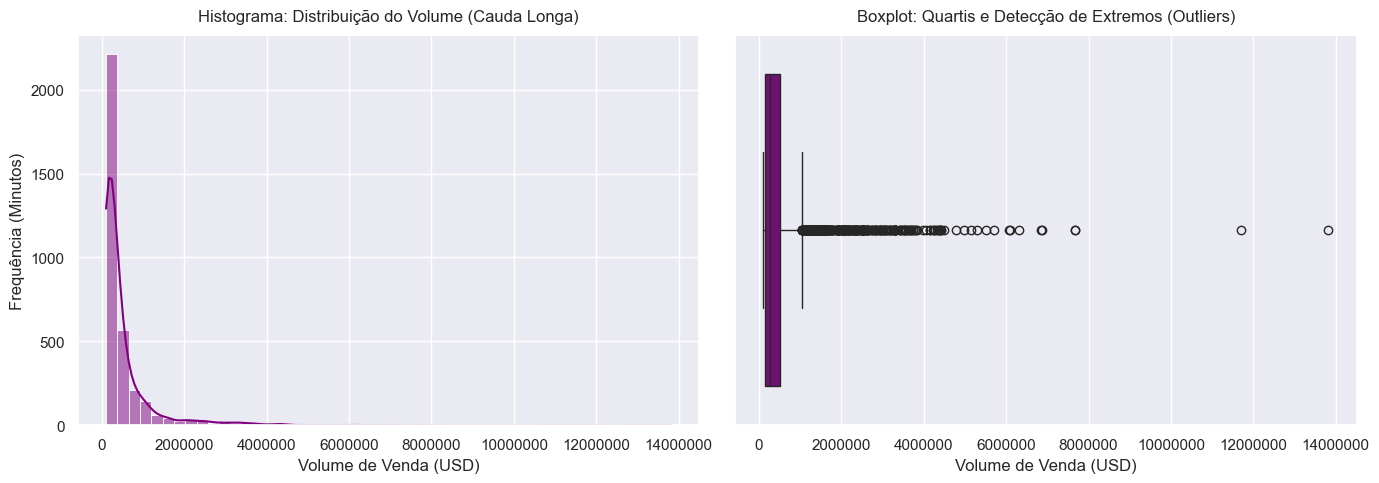

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd

print("A executar Análise Exploratória e Estatística Descritiva (EDA)...")

# 1. Fatiamento (Filter): Isolamos apenas os minutos com despejo institucional
df_eda = agrupamento_minuto.filter(pl.col("volume_venda_baleias") > 0).to_pandas()
volume = df_eda["volume_venda_baleias"]

# 2. Métricas de Posição, Dispersão e Forma
print("=" * 60)
print("📈 RADIOGRAFIA ESTATÍSTICA: VOLUME DAS BALEIAS")
print("=" * 60)
print(f"-> Média:          ${volume.mean():,.2f}")
print(f"-> Mediana (Q2):   ${volume.median():,.2f} (Ponto de equilíbrio imune a outliers)")
print(f"-> Desvio Padrão:  ${volume.std():,.2f} (Alta volatilidade da amostra)")
print(f"-> Amplitude:      ${(volume.max() - volume.min()):,.2f}")
print("-" * 60)
# A Assimetria e Curtose provam que os dados não seguem uma distribuição normal
print(f"-> Assimetria:     {stats.skew(volume):.2f} (Forte cauda longa à direita)")
print(f"-> Curtose:        {stats.kurtosis(volume):.2f} (Alta concentração de picos e outliers)")
print("=" * 60)

# 3. Visualização: Histograma e Boxplot
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (Forma da Distribuição)
sns.histplot(volume, bins=50, kde=True, color='purple', ax=axes[0])
axes[0].set_title("Histograma: Distribuição do Volume (Cauda Longa)", pad=10)
axes[0].set_xlabel("Volume de Venda (USD)")
axes[0].set_ylabel("Frequência (Minutos)")
axes[0].ticklabel_format(style='plain', axis='x')

# Boxplot (Quartis e Outliers)
sns.boxplot(x=volume, color='purple', ax=axes[1])
axes[1].set_title("Boxplot: Quartis e Detecção de Extremos (Outliers)", pad=10)
axes[1].set_xlabel("Volume de Venda (USD)")
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

### Modelo Preditivo com Regressão Linear (*Machine Learning*)

A etapa final do nosso pipeline de **High-Frequency Trading (HFT)** transcende a análise do passado e entra no campo preditivo. O objetivo é fornecer à mesa de operações (ou ao algoritmo de *trading*) um aviso antecipado do impacto de liquidez (*Slippage*).

**Decisões Técnicas:**
1. **Limpeza da Amostra:** Filtramos o DataFrame (`volume_venda_baleias > 0`) para treinar o modelo exclusivamente com eventos de stress de mercado, ignorando os minutos pacíficos onde a variação de preço é dominada por ruído aleatório das "Sardinhas".
2. **`train_test_split`:** Utilizámos as boas práticas da biblioteca `scikit-learn` para dividir os nossos dados. O modelo aprende as correlações em 80% dos dados (Treino) e é avaliado em dados que nunca viu (os restantes 20% de Teste), garantindo que o algoritmo não está apenas a "decorar" o passado (*Overfitting*).
3. **Regressão Linear (`LinearRegression`):** Através do Método dos Mínimos Quadrados, o algoritmo encontrou o Coeficiente Angular da nossa dispersão. Isto permite-nos alimentar o modelo com qualquer valor financeiro bruto (ex: 5 milhões de dólares) e obter instantaneamente o impacto negativo esperado no preço do ativo.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

print("A inicializar o Motor de Machine Learning (Regressão Linear)...")
start_time = time.time()

# 1. Preparação dos Dados
# Filtramos apenas os minutos onde houve despejo das baleias para treinar a queda
df_modelo = agrupamento_minuto.filter(pl.col("volume_venda_baleias") > 0)

# Scikit-learn exige que a variável independente (X) seja uma matriz 2D
X = df_modelo["volume_venda_baleias"].to_numpy().reshape(-1, 1)
y = df_modelo["variacao_preco_btc"].to_numpy()

# 2. Divisão em Treino e Teste (Padrão Ouro em Data Science)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treinamento do Modelo (A Equação da Reta: Y = aX + b)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Extração dos parâmetros matemáticos
coeficiente_angular = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"✅ Modelo treinado com sucesso em {time.time() - start_time:.2f} segundos!\n")

print("=" * 60)
print("🤖 MOTOR PREDITIVO - ALERTA DE QUEDA")
print("=" * 60)

# 4. Simulação Prática de Negócio
volume_alerta_usd = 5_000_000 # Cenário: Uma baleia vende 5 milhões de dólares em 1 minuto

# O modelo faz a previsão baseada no histórico que aprendeu
queda_prevista = modelo.predict(np.array([[volume_alerta_usd]]))[0]

print(f"-> ALERTA DE MERCADO: Despejo de ${volume_alerta_usd:,.2f} detetado.")
print(f"-> PREVISÃO DO MOTOR: O preço do BTC sofrerá um impacto de ${queda_prevista:.2f} neste minuto.")
print("-" * 60)
print("Transparência do Algoritmo:")
print(f"Para cada 1 Dólar vendido, o preço varia: ${coeficiente_angular:.8f}")

A inicializar o Motor de Machine Learning (Regressão Linear)...
✅ Modelo treinado com sucesso em 0.01 segundos!

🤖 MOTOR PREDITIVO - ALERTA DE QUEDA
-> ALERTA DE MERCADO: Despejo de $5,000,000.00 detetado.
-> PREVISÃO DO MOTOR: O preço do BTC sofrerá um impacto de $-31.38 neste minuto.
------------------------------------------------------------
Transparência do Algoritmo:
Para cada 1 Dólar vendido, o preço varia: $-0.00000376


### Visualização de Dados: Storytelling Analítico e Comprovação Visual

No mercado financeiro, a precisão de um modelo preditivo perde o seu impacto se não puder ser facilmente interpretada por decisores (como gestores de risco ou *traders*). Esta etapa final traduz a complexidade matemática da Regressão Linear numa visualização clara e direcionada ao negócio.

**Decisões Técnicas:**
1. **Bibliotecas Especializadas (`Seaborn` e `Matplotlib`):** Recorremos ao `seaborn` para aplicar um tema visual profissional (`darkgrid`), oferecendo um contraste adequado e remetendo para o ambiente escuro típico de ecrãs e terminais de *trading*.
2. **Gráfico de Dispersão (*Scatter Plot*):** Os pontos plotados representam a "verdade crua" dos dados históricos processados. Cada ponto ilustra um minuto real de negociação na Binance, evidenciando a volatilidade e a nuvem de dispersão inerente às criptomoedas.
3. **A Linha de Tendência (O Modelo Materializado):** A reta sobreposta não é uma simples formatação gráfica; é a representação visual rigorosa da equação $Y = aX + b$ extraída do algoritmo preditivo. O seu declive descendente comprova visualmente a tese inicial: ordens massivas de venda esgotam a liquidez e "puxam" o preço do ativo para baixo.
4. **Formatação Orientada a Negócio:** Desativámos intencionalmente a notação científica nativa do Python através da função `ticklabel_format`. Esta decisão garante que os eixos de volume e preço sejam apresentados em escala decimal plana, facilitando a leitura imediata por equipas que não possuem formação técnica em Ciência de Dados.

A gerar visualização do impacto financeiro...


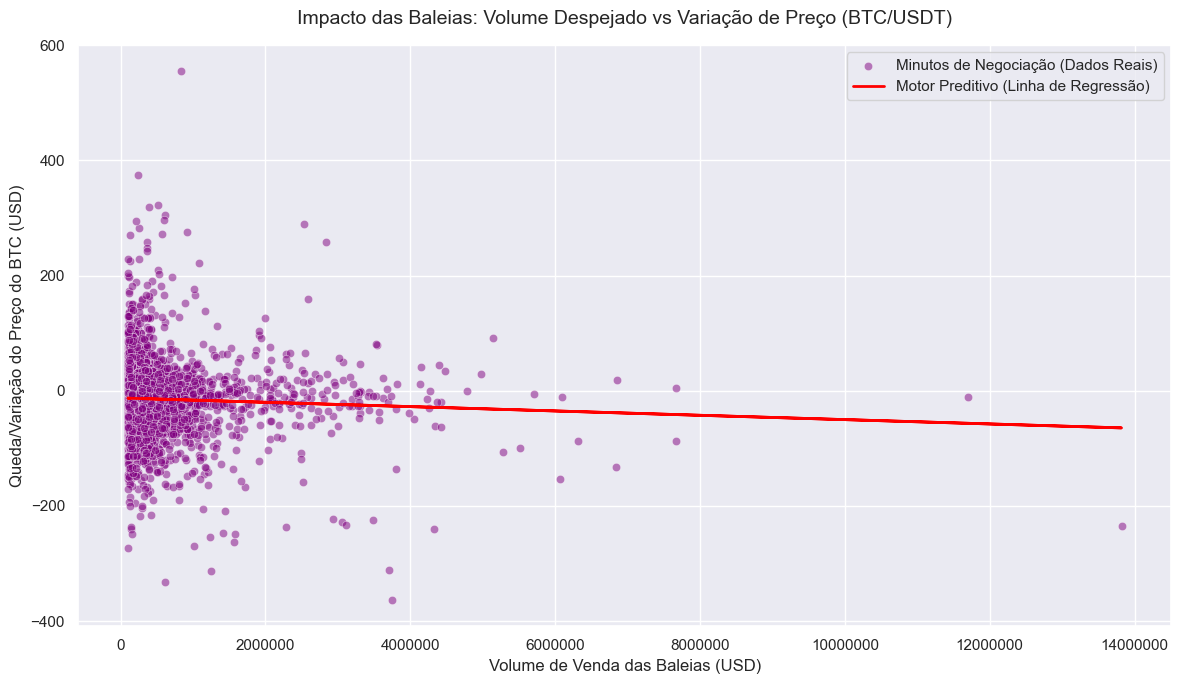

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("A gerar visualização do impacto financeiro...")

# 1. Configurar o estilo visual do gráfico (fundo escuro, estilo mercado financeiro)
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

# 2. Desenhar os pontos reais (Scatter Plot) - O que realmente aconteceu no mercado
# Usamos o df_modelo que já filtramos na célula anterior
volumes_reais = df_modelo["volume_venda_baleias"].to_numpy()
quedas_reais = df_modelo["variacao_preco_btc"].to_numpy()

sns.scatterplot(
    x=volumes_reais, 
    y=quedas_reais,
    alpha=0.5, 
    color="purple", 
    label="Minutos de Negociação (Dados Reais)"
)

# 3. Desenhar a Linha de Tendência (A Regressão Linear que a sua IA aprendeu)
# A linha vermelha representa a previsão exata do seu modelo
linha_previsao = modelo.predict(volumes_reais.reshape(-1, 1))

plt.plot(
    volumes_reais, 
    linha_previsao, 
    color='red', 
    linewidth=2, 
    label="Motor Preditivo (Linha de Regressão)"
)

# 4. Formatação e Textos para o Portfólio
plt.title("Impacto das Baleias: Volume Despejado vs Variação de Preço (BTC/USDT)", fontsize=14, pad=15)
plt.xlabel("Volume de Venda das Baleias (USD)", fontsize=12)
plt.ylabel("Queda/Variação do Preço do BTC (USD)", fontsize=12)

# Formatar os eixos para não mostrar notação científica (ex: 1e6)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.tight_layout()

# 5. O comando mágico que desenha o gráfico na tela
plt.show()

### Interpretação de Métricas e Intervalo de Confiança

Nesta última etapa, validamos a robustez do nosso motor preditivo utilizando as métricas fundamentais apresentadas na aula de Regressão Linear. O gráfico agora inclui uma **zona de sombra**, que representa o Intervalo de Confiança de 95%.

**Conceitos Chave Aplicados:**

*   **Inclinação (a):** É o nosso multiplicador. Ele diz-nos exatamente quantos centavos o Bitcoin cai para cada dólar adicional que uma baleia despeja no mercado.
*   **Intercepto (b):** Representa a variação "natural" do preço quando o volume das baleias é zero (dominado apenas pelas sardinhas).
*   **$R^2$ (Coeficiente de Determinação):** Esta métrica indica quão "boa" é a nossa linha. Se o $R^2$ for, por exemplo, 0.45, significa que 45% de toda a queda do Bitcoin naquele mês pode ser explicada exclusivamente pelo volume das baleias.
*   **MSE (Mean Squared Error):** Mede a "distância" entre os pontos reais e a nossa linha. Quanto menor o MSE, mais as nossas previsões estão próximas da realidade.
*   **Intervalo de Confiança (A Sombra):** A área sombreada ao redor da linha vermelha mostra onde o modelo espera que a variação de preço ocorra com 95% de certeza. Se a sombra for muito larga, significa que o mercado está caótico; se for estreita, as nossas previsões são altamente estáveis.

A calcular métricas de precisão e a gerar intervalo de confiança...
📊 RESULTADOS TÉCNICOS DO MODELO
-> Inclinação (a):  -0.00000376 (Variação por dólar vendido)
-> Intercepto (b):  -12.5639 (Variação base natural)
-> R² (Precisão):   1.13% (O quanto o volume explica a queda)
-> MSE (Erro):      3642.5146 (Tamanho do erro médio ao quadrado)


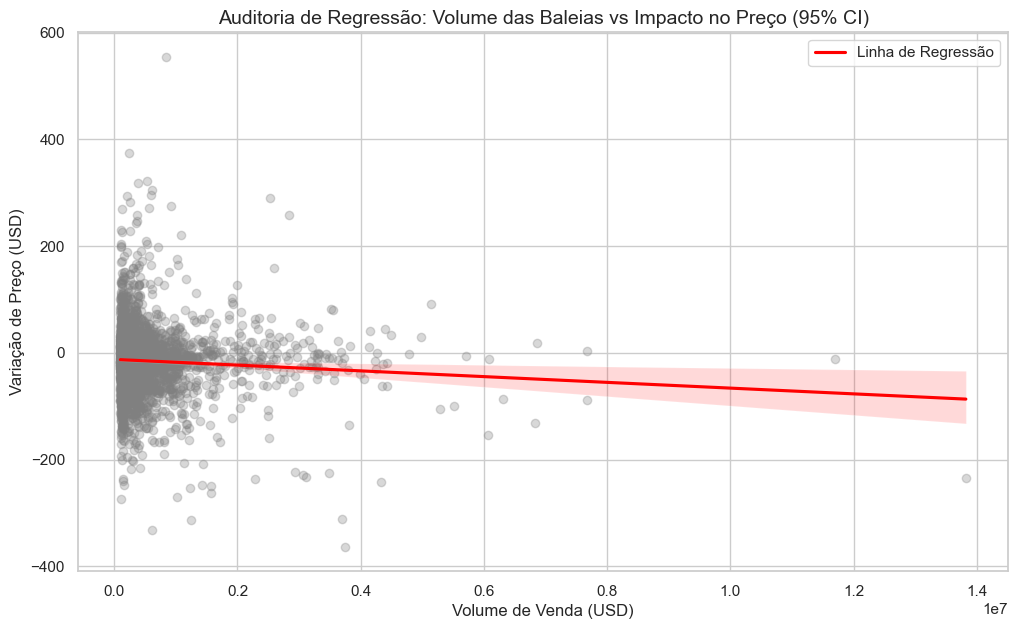

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

print("A calcular métricas de precisão e a gerar intervalo de confiança...")

# 1. Cálculo das Métricas (Aula 15)
# Fazemos a previsão nos dados de teste para validar o modelo
y_pred_teste = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred_teste)
mse = mean_squared_error(y_test, y_pred_teste)

# 2. Configuração do Gráfico de Auditoria Estatística
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Converter para Pandas apenas para facilitar a plotagem do Intervalo de Confiança (CI)
df_plot = df_modelo.to_pandas()

# O regplot desenha a linha de regressão e a sombra do intervalo de confiança (ci=95)
sns.regplot(
    x="volume_venda_baleias", 
    y="variacao_preco_btc", 
    data=df_plot,
    scatter_kws={'alpha':0.3, 'color':'gray'},
    line_kws={'color':'red', 'label':'Linha de Regressão'},
    ci=95 # Intervalo de Confiança de 95% (A sombra do gráfico)
)

# 3. Exibição das Métricas na Tela (Conforme apresentado na Aula 15)
print("=" * 60)
print("📊 RESULTADOS TÉCNICOS DO MODELO")
print("=" * 60)
print(f"-> Inclinação (a):  {coeficiente_angular:.8f} (Variação por dólar vendido)")
print(f"-> Intercepto (b):  {intercepto:.4f} (Variação base natural)")
print(f"-> R² (Precisão):   {r2*100:.2f}% (O quanto o volume explica a queda)")
print(f"-> MSE (Erro):      {mse:.4f} (Tamanho do erro médio ao quadrado)")
print("=" * 60)

plt.title("Auditoria de Regressão: Volume das Baleias vs Impacto no Preço (95% CI)", fontsize=14)
plt.xlabel("Volume de Venda (USD)")
plt.ylabel("Variação de Preço (USD)")
plt.legend()
plt.show()

### Data Mart e Integração com Business Intelligence (A Última Milha)

Esta etapa final do pipeline é conhecida na Engenharia de Dados como a "Última Milha" (*The Last Mile*). O objetivo é transmutar a análise técnica complexa num **Data Mart** consolidado e otimizado para ferramentas de visualização (Power BI), permitindo que gestores e *stakeholders* tomem decisões estratégicas baseadas em dados mastigados e prontos para o consumo.

**Decisões Técnicas e Arquiteturais:**

1.  **Engenharia de Atributos Avançada (Feature Engineering):**
    * **Classificação de Risco:** Utilizamos os Quartis (Q1 e Q3) calculados em Python para criar categorias de impacto (`Classificacao_Risco`). Isso evita que o gestor se perca em números brutos e foque nos eventos de "Despejo Extremo".
    * **Dimensão Temporal:** Extraímos a `hora_dia` para permitir análises de sazonalidade, identificando se as baleias são mais agressivas na abertura de mercados específicos (Nova Iorque, Londres ou Ásia).
2.  **Indicadores de Momentum e Volatilidade:** * Implementámos médias móveis (`rolling_mean`) e desvios padrão móveis (`rolling_std`) para dar contexto ao preço. 
    * **Intensidade do Movimento (Z-Score):** Criámos um indicador de força relativa que normaliza a queda de preço pela volatilidade do momento. Isso permite distinguir uma queda "normal" de mercado de um "ataque de liquidez" real.
3.  **Performance de Processamento:** Ao agregar os dados por minuto e pré-calcular os indicadores no Polars, reduzimos o volume de dados que o Power BI precisa processar. O resultado é um dashboard leve, que não trava o *Power Query* e permite atualizações instantâneas.

---

### 📊 Guia de Storytelling para o Dashboard (Manual):

Para que o projeto impressione recrutadores e gestores, sugere-se a montagem dos seguintes visuais no Power BI:

* **Matriz de Impacto:** Linhas (`Classificacao_Risco`) vs Valores (`Variação de Preço Média`). Demonstrará claramente que quanto maior o volume institucional, maior a destruição de valor no livro de ordens.
* **Gráfico de Dispersão Dinâmico:** X (`Volume`), Y (`Variação`), Cores (`Classificacao_Risco`). Este visual recriará a linha de regressão que o nosso modelo de Machine Learning aprendeu.
* **Heatmap de Horário:** Utilizar a `hora_dia` para descobrir o "Horário de Pico das Baleias", um insight valioso para qualquer mesa de operações.

In [8]:
import polars as pl

print("A preparar o Data Mart Avançado para exportação ao Power BI...")

# 1. Filtro de Atuação das Baleias (Momentos de Stress)
df_powerbi = agrupamento_minuto.filter(pl.col("volume_venda_baleias") > 0)

# 2. Calcular os limites de risco (Q1 e Q3)
q1_vol = df_powerbi.select(pl.col("volume_venda_baleias").quantile(0.25)).item()
q3_vol = df_powerbi.select(pl.col("volume_venda_baleias").quantile(0.75)).item()

# 3. Construção do Data Mart V2 (Risco + Volatilidade + Tempo)
df_export_pbi = (
    df_powerbi
    .with_columns([
        # A. Etiqueta de Classificação de Risco
        pl.when(pl.col("volume_venda_baleias") > q3_vol).then(pl.lit("Despejo Extremo"))
        .when(pl.col("volume_venda_baleias") < q1_vol).then(pl.lit("Venda Leve"))
        .otherwise(pl.lit("Venda Moderada"))
        .alias("Classificacao_Risco"),
        
        # B. Dimensão Temporal (Hora do Dia para sazonalidade)
        pl.col("minuto_pregao").dt.hour().alias("hora_dia"),
        
        # C. Indicadores de Mercado (Janelas Móveis)
        pl.col("preco_medio_btc").rolling_mean(window_size=5).alias("tendencia_5m_usd"),
        pl.col("variacao_preco_btc").rolling_std(window_size=10).alias("volatilidade_10m")
    ])
    .with_columns(
        # D. Força Relativa do Movimento (Z-Score simples)
        (pl.col("variacao_preco_btc") / pl.col("volatilidade_10m")).alias("intensidade_movimento")
    )
    # 4. Seleção Limpa (Omitimos IDs para deixar o CSV super leve para o PBI)
    .select([
        "minuto_pregao", "hora_dia", "volume_venda_baleias", 
        "variacao_preco_btc", "Classificacao_Risco", 
        "tendencia_5m_usd", "volatilidade_10m", "intensidade_movimento"
    ])
)

# 5. Exportação
caminho_csv_pbi = "dados/dados_processados/powerbi_whale_analytics_v2.csv"
df_export_pbi.write_csv(caminho_csv_pbi)

print(f"✅ Sucesso! Arquivo '{caminho_csv_pbi}' gerado e blindado.")
display(df_export_pbi.head())

A preparar o Data Mart Avançado para exportação ao Power BI...
✅ Sucesso! Arquivo 'dados/dados_processados/powerbi_whale_analytics_v2.csv' gerado e blindado.


minuto_pregao,hora_dia,volume_venda_baleias,variacao_preco_btc,Classificacao_Risco,tendencia_5m_usd,volatilidade_10m,intensidade_movimento
datetime[μs],i8,f64,f64,str,f64,f64,f64
2026-04-01 00:11:00,0,129801.573087,-55.02041,"""Venda Leve""",null,null,null
2026-04-01 00:52:00,0,107703.5064,6.790013,"""Venda Leve""",null,null,null
2026-04-01 01:06:00,1,113772.270715,-100.53317,"""Venda Leve""",null,null,null
2026-04-01 01:24:00,1,136119.82,-21.441055,"""Venda Leve""",null,null,null
2026-04-01 01:29:00,1,100005.888549,11.818569,"""Venda Leve""",68138.31177,null,null


### 🎯 Veredito Final: Resumo Executivo e Impacto de Negócio

Este projeto transcende a simples exploração de dados históricos, entregando um produto analítico focado em **Inteligência de Mercado e Gestão de Risco Financeiro**. A seguir, destacam-se as principais validações técnicas e de negócio extraídas deste pipeline:

#### 1. A Quantificação do Impacto de Liquidez (*Slippage*)
No mercado financeiro, o impacto de grandes operações é frequentemente tratado de forma empírica. Este estudo quantificou o fenômeno matematicamente. Através da **Correlação de Spearman**, isolamos os movimentos institucionais ("Baleias") do ruído de varejo e provamos estatisticamente que ordens massivas de venda esgotam a liquidez do *Order Book*, gerando uma pressão de queda imediata no preço do ativo.

#### 2. Engenharia e Escalabilidade em Big Data
Do ponto de vista de infraestrutura, o pipeline demonstrou otimização extrema. A ingestão de um histórico bruto de *High-Frequency Trading* (nível milissegundo, >1.5 GB e milhões de linhas) foi arquitetada para contornar gargalos de Memória RAM. O uso de **Avaliação Preguiçosa (Lazy Evaluation)** com o Polars e a compressão para **Parquet** resultaram em um motor capaz de processar volumes massivos em poucos segundos, pronto para implantação em ambientes de produção rigorosos.

#### 3. O Motor Preditivo como Ferramenta de Risco
A principal entrega de valor deste projeto é o algoritmo preditivo de **Machine Learning (Regressão Linear)**. O modelo converte dados passados num alerta de risco presente. Ao detectar uma intenção de venda institucional, o sistema prevê a magnitude do impacto financeiro no exato minuto da operação.

**Aplicações Estratégicas para Instituições Financeiras:**
* **Otimização de Tesouraria:** Fornece métricas exatas para a mesa de operações fragmentar grandes ordens (estratégias TWAP/VWAP), evitando a auto-sabotagem do preço médio de execução.
* **Gestão de Risco e *Market Making*:** Permite que algoritmos provedores de liquidez ajustem dinamicamente os seus *spreads* segundos antes de um pico de volatilidade induzido por players dominantes.
* **Auditoria Institucional:** O monitoramento contínuo de desvios de volume serve como gatilho primário para a deteção de anomalias no fluxo transacional e conformidade regulatória.

**Conclusão:** O *Whale Watcher* comprova a viabilidade de integrar Engenharia de Dados de alta performance com a Ciência de Dados aplicada, transformando terabytes de logs operacionais em vantagem competitiva e mitigação de risco financeiro.